# RandomForest - Cadre methodologique modulaire

Ce notebook applique un cadre methodologique reproductible et modulaire avec un modele RandomForest.

Il permet de :
- definir des profils (donnees, pretraitement, representation, modele, evaluation),
- executer une pipeline coherente pour l'approche A (agregation) ou B (fenetrage temporel),
- produire une fiche modele avec metriques et sorties graphiques.

In [ ]:
import os
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from rf_pipeline.extract import add_target, load_csv_features, load_mat_matrix
from rf_pipeline.pretraitement import apply_preprocess, apply_target_discretization, prepare_splits_and_impute
from rf_pipeline.visu_pretraitement import plot_feature_report, plot_preprocessing_report, plot_split_report
from rf_pipeline.models import fit_final_model, run_hyperparam_search
from rf_pipeline.evaluation import (
    evaluate_by_subject,
    evaluate_robustness,
    evaluate_test_set,
    plot_feature_importance,
    plot_pca_if_classification,
)
from rf_pipeline.reporting import build_model_card, save_outputs

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

print(f"Seed globale: {SEED}")

## 1) Profils modulaires

In [11]:
# Ajuster ces profils pour chaque experience
# Template source: rf_pipeline/config.py (markdown a copier-coller)

DATA_PROFILE = {
    "source": "csv",
    "file_path": r"../data/Indicateurs calculés/FullTimeIndicatorsMinutes1.csv",
    "subject_id_col": "Participant",
    "feature_columns": {
        0: "Time",
        1: "HMDPosX",
        2: "HMDPosY",
        3: "HMDPosZ",
        4: "RotX",
        5: "RotY",
        6: "RotZ",
        7: "SuggestedRotationX",
        8: "SuggestedRotationY",
        9: "SuggestedRotationZ",
        10: "LeftPupilDiameter",
        11: "RightPupilDiameter",
        12: "XGazeDirection",
        13: "YGazeDirection",
        14: "Confidence",
        15: "IsBoat",
        16: "XWorldPosition",
        17: "YWorldPosition",
    },
    "subject_id_count_hint": 42,
}

REPRESENTATION_PROFILE = {
    "approach": "A",
    "drop_time_column": True,
    "aggregated_stats": ["mean", "std", "min", "max", "median", "q25", "q75", "slope"],
    "window_length": 60,
    "window_stride": 30,
}

PREPROCESS_PROFILE = {
    "clip_quantiles": [0.01, 0.99],
    "imputation_strategy": "median",
    "drop_low_information_features": True,
    "min_valid_features": 1,
    "normalization": None,  # None | "standard" | "minmax"
}

TARGET_PROFILE = {
    "source": "xlsx",
    "xlsx_path": r"../data/Questionnaires/FMS1_org.xlsx",
    "sheet_name": "Feuil1",
    "subject_id_col": "Sujet",
    "target_mode": "per_minute",
    "minute_columns": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
    "minute_col": "Minute",
    "discretize": {
        "bins":   [0, 5, 10, 20],
        "labels": ["low", "medium", "high"],
    },
}

MODEL_PROFILE = {
    "model_type": "random_forest",  # random
    "task_type": "regression",  # classification / regression
    "split_method": "group",        # group / random
    "test_size": 0.20,
    "val_size": 0.20,
    "class_weight": "balanced",
    "random_state": SEED,
}

EVAL_PROFILE = {
    "robustness_noise_std": 0.01,
    "robustness_repeats": 5,
}

OUTPUT_PROFILE = {
    "output_dir": r"../data/outputs/random_forest_modulaire",
    "save_model_card": True,
}

print("Profils charges depuis la cellule notebook (template config.py)")
print("Data source :", DATA_PROFILE["source"])
print("Approche :", REPRESENTATION_PROFILE["approach"])
print("Tache :", MODEL_PROFILE["task_type"])
print("Target source :", TARGET_PROFILE["source"])
print("Mode cible :", TARGET_PROFILE.get("target_mode", "n/a"))
print("Normalisation :", PREPROCESS_PROFILE.get("normalization") or "aucune")

Profils charges depuis la cellule notebook (template config.py)
Data source : csv
Approche : A
Tache : regression
Target source : xlsx
Mode cible : per_minute
Normalisation : aucune


## 3) Construction de representation (Approche A ou B)

In [12]:
if DATA_PROFILE["source"] == "csv":
    features_df = load_csv_features(DATA_PROFILE)
    print("Source CSV detectee: les features sont chargees telles quelles.")

elif DATA_PROFILE["source"] == "mat":
    mat_dict, data_matrix, subject_ids = load_mat_matrix(DATA_PROFILE)
    raise NotImplementedError(
        "Le chemin MAT doit maintenant etre orchestre via des fonctions dediees dans rf_pipeline si necessaire."
    )

else:
    raise ValueError("DATA_PROFILE['source'] doit etre 'csv' ou 'mat'.")

print("Representation construite:", REPRESENTATION_PROFILE["approach"])
print("Shape:", features_df.shape)
display(features_df.head())

Source CSV detectee: les features sont chargees telles quelles.
Representation construite: A
Shape: (588, 34)


,subject_id,Minute,Amp01X,Amp01Y,Amp01Z,Amp04X,Amp04Y,Amp04Z,TotMovX,TotMovY,...,%Pow01EyeX,%Pow01EyeY,%Pow04EyeX,%Pow04EyeY,Ellipse95Eye,Ellipse95WorldPos,PupilDiamX,PupilDiamY,%Boat,row_id
0,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,0933,1,0.138978,0.095120,0.016308,0.084265,0.100830,0.173925,2166.960484,9533.470190,...,2.561688,4.804704,0.038757,4.804704,0.123952,319.224603,3.333145,3.465322,1.587302,1
2,7180bt,1,0.391176,0.661502,0.023081,0.038081,0.352528,0.221892,5054.512261,6774.620885,...,2.062268,0.908652,0.858235,0.908652,0.070573,217.640225,3.777876,3.725042,17.126149,2
3,22009611,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
4,ab0710,1,0.060397,0.068861,0.002310,0.038956,0.153820,0.089738,647.350744,912.905124,...,1.433131,8.315259,2.756813,8.315259,0.159130,194.315384,4.082976,3.888957,2.172097,4


## 4) Integration de la cible

In [13]:
dataset_df = add_target(features_df, TARGET_PROFILE)

print("Dataset avec cible:", dataset_df.shape)
print("Apercu colonnes:", dataset_df.columns[:10].tolist())
display(dataset_df.head())

Dataset avec cible: (522, 36)
Apercu colonnes: ['subject_id', 'Minute', 'Amp01X', 'Amp01Y', 'Amp01Z', 'Amp04X', 'Amp04Y', 'Amp04Z', 'TotMovX', 'TotMovY']


,subject_id,Minute,Amp01X,Amp01Y,Amp01Z,Amp04X,Amp04Y,Amp04Z,TotMovX,TotMovY,...,%Pow04EyeX,%Pow04EyeY,Ellipse95Eye,Ellipse95WorldPos,PupilDiamX,PupilDiamY,%Boat,row_id,minute,target
0,7180bt,1,0.391176,0.661502,0.023081,0.038081,0.352528,0.221892,5054.512261,6774.620885,...,0.858235,0.908652,0.070573,217.640225,3.777876,3.725042,17.126149,2,1,7.0
1,22009611,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,1,4.0
2,ab0710,1,0.060397,0.068861,0.002310,0.038956,0.153820,0.089738,647.350744,912.905124,...,2.756813,8.315259,0.159130,194.315384,4.082976,3.888957,2.172097,4,1,8.0
3,am3001,1,0.063596,0.014971,0.032345,0.095778,0.044423,0.032648,1922.915362,793.806587,...,0.215129,8.185577,0.103624,157.331180,5.250478,5.144878,0.751880,5,1,3.0
4,AP1133,1,0.009319,0.003780,0.003951,0.003373,0.033734,0.053038,108.184186,114.219420,...,1.963714,31.873764,0.034554,41.801993,3.533532,3.688725,0.000000,6,1,4.0


## 5) Pretraitement, split et preparation

In [14]:

dataset_df = apply_target_discretization(dataset_df, TARGET_PROFILE)

if TARGET_PROFILE.get("discretize"):
    print("Classes apres discretisation:", dataset_df["target"].unique().tolist())
    print("Distribution:")
    print(dataset_df["target"].value_counts().sort_index())

raw_df = dataset_df.copy()
dataset_df, feature_cols = apply_preprocess(dataset_df, PREPROCESS_PROFILE)

prepared = prepare_splits_and_impute(
    dataset_df=dataset_df,
    feature_cols=feature_cols,
    preprocess_profile=PREPROCESS_PROFILE,
    model_profile=MODEL_PROFILE,
)

X_train_imp = prepared["X_train_imp"]
X_val_imp = prepared["X_val_imp"]
X_test_imp = prepared["X_test_imp"]
y_train = prepared["y_train"]
y_val = prepared["y_val"]
y_test = prepared["y_test"]
train_idx = prepared["train_idx"]
val_idx = prepared["val_idx"]
test_idx = prepared["test_idx"]
imputer = prepared["imputer"]
scaler = prepared["scaler"]

print("Dataset final:", dataset_df.shape)
print("Nombre de features:", len(feature_cols))
print("Split sizes -> train/val/test:", len(train_idx), len(val_idx), len(test_idx))
if scaler is not None:
    print("Normalisation appliquee:", type(scaler).__name__)

Classes apres discretisation: ['medium', 'low', 'high']
Distribution:
target
low       318
medium    153
high       51
Name: count, dtype: int64


KeyError: 'scaler'

## 5.bis) Visualisation du pretraitement

In [ ]:
plot_preprocessing_report(raw_df, dataset_df, feature_cols, PREPROCESS_PROFILE)

plot_split_report(dataset_df, train_idx, val_idx, test_idx, MODEL_PROFILE)

## 5.ter) Visualisation des features

In [ ]:
plot_feature_report(dataset_df, feature_cols, MODEL_PROFILE)

## 6) Optimisation hyperparametres et entrainement

In [ ]:
best_params, results_df = run_hyperparam_search(
    X_train_imp=X_train_imp,
    y_train=y_train,
    X_val_imp=X_val_imp,
    y_val=y_val,
    model_profile=MODEL_PROFILE,
)

display(results_df.head(10))
print("Best params:", best_params)

final_model = fit_final_model(
    X_train_imp=X_train_imp,
    y_train=y_train,
    X_val_imp=X_val_imp,
    y_val=y_val,
    best_params=best_params,
    model_profile=MODEL_PROFILE,
)

,class_weight,max_depth,max_features,min_samples_leaf,min_samples_split,n_estimators,val_accuracy,val_f1_weighted
0,balanced,10.0,log2,2,5,200,0.401786,0.374372
1,balanced,10.0,sqrt,2,5,200,0.401786,0.374372
2,balanced,10.0,sqrt,1,5,200,0.428571,0.371684
3,balanced,10.0,log2,1,5,200,0.428571,0.371684
4,balanced,10.0,log2,1,5,500,0.419643,0.367358
5,balanced,10.0,sqrt,1,5,500,0.419643,0.367358
6,balanced,10.0,sqrt,2,2,200,0.410714,0.365710
7,balanced,10.0,log2,2,2,200,0.410714,0.365710
8,balanced,NaN,sqrt,2,5,200,0.392857,0.364423
9,balanced,NaN,log2,2,5,200,0.392857,0.364423


Best params: {'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


## 7) Evaluation, robustesse et visualisations

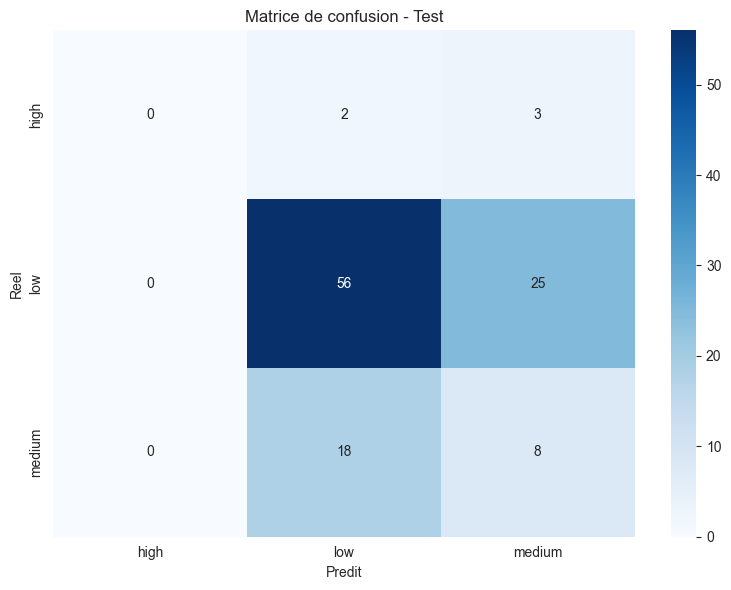

accuracy              0.571429
precision_weighted    0.584482
recall_weighted       0.571429
f1_weighted           0.575831
dtype: float64

Classification report:
              precision    recall  f1-score   support

        high       0.00      0.00      0.00         5
         low       0.74      0.69      0.71        81
      medium       0.22      0.31      0.26        26

    accuracy                           0.57       112
   macro avg       0.32      0.33      0.32       112
weighted avg       0.58      0.57      0.58       112



,subject_id,n,accuracy,f1_weighted
0,BM1997,14.0,0.571429,0.475000
1,CH1308,14.0,0.571429,0.727273
2,FC1997,14.0,0.714286,0.833333
3,NB1934,14.0,0.357143,0.526316
4,NT1234,14.0,0.642857,0.670807
5,RU3300,14.0,0.571429,0.520408
6,ab0710,14.0,0.357143,0.407143
7,rl2704,14.0,0.785714,0.817143


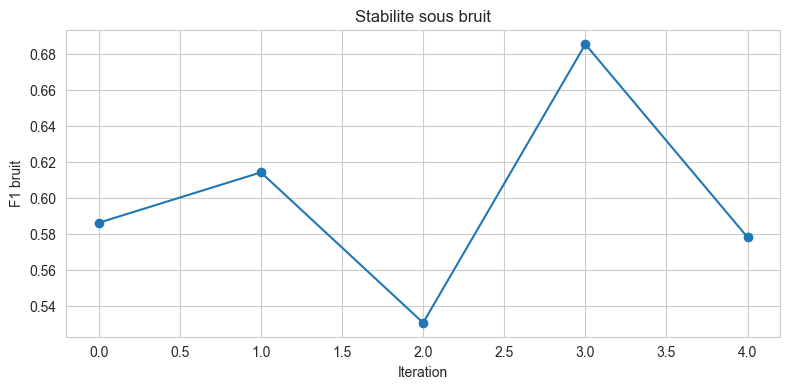

Score robustesse (moyenne): 0.5990445497759334


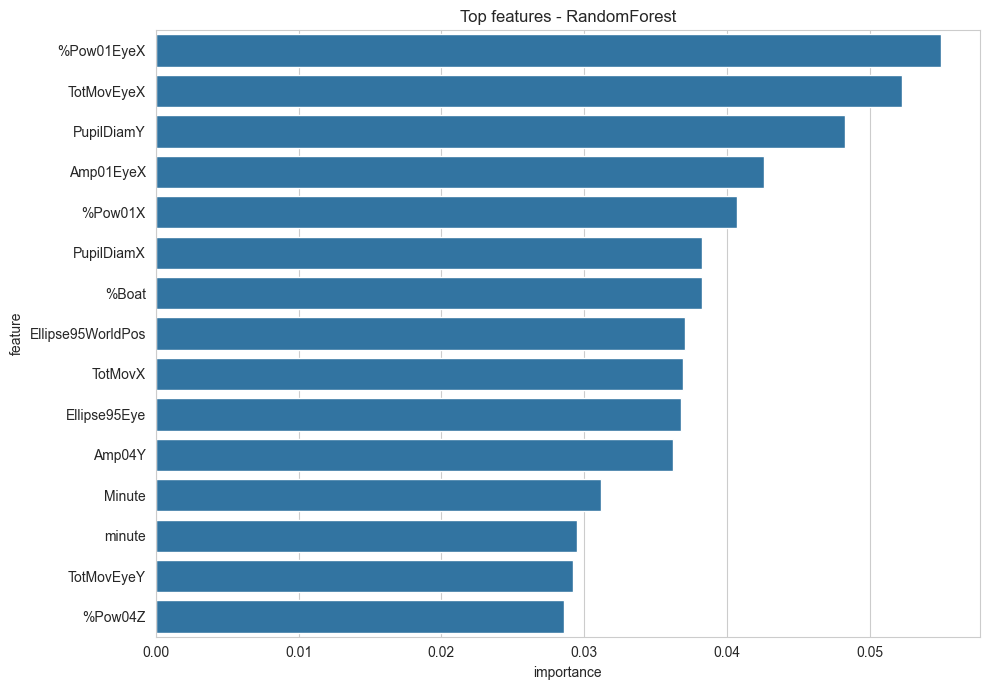

,feature,importance
23,%Pow01EyeX,0.054956
21,TotMovEyeX,0.052214
30,PupilDiamY,0.048233
17,Amp01EyeX,0.042597
11,%Pow01X,0.040681
29,PupilDiamX,0.038230
31,%Boat,0.038218
28,Ellipse95WorldPos,0.037042
7,TotMovX,0.036918
27,Ellipse95Eye,0.036801


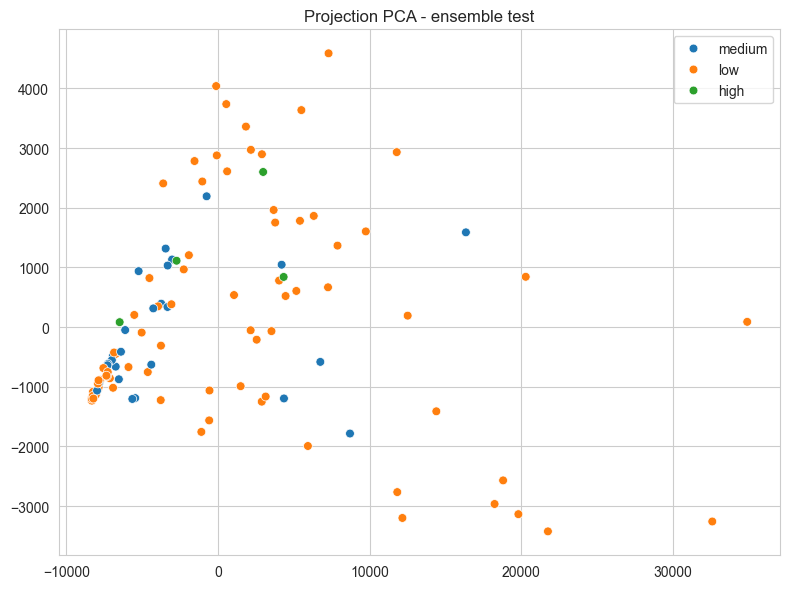

In [ ]:
pred_test, metrics, classification_text_report = evaluate_test_set(
    final_model=final_model,
    X_test_imp=X_test_imp,
    y_test=y_test,
    model_profile=MODEL_PROFILE,
    show_plots=True,
)

print(pd.Series(metrics))
if classification_text_report is not None:
    print("\nClassification report:")
    print(classification_text_report)

by_subject = evaluate_by_subject(
    dataset_df=dataset_df,
    test_idx=test_idx,
    y_test=y_test,
    pred_test=pred_test,
    model_profile=MODEL_PROFILE,
)
display(by_subject.head(20))

noise_scores = evaluate_robustness(
    final_model=final_model,
    X_test_imp=X_test_imp,
    y_test=y_test,
    model_profile=MODEL_PROFILE,
    eval_profile=EVAL_PROFILE,
    seed=SEED,
    show_plot=True,
)
print("Score robustesse (moyenne):", float(np.mean(noise_scores)))

imp_df = plot_feature_importance(final_model, feature_cols, top_n=15)
if imp_df is not None:
    display(imp_df.head(20))

plot_pca_if_classification(X_test_imp, y_test, MODEL_PROFILE, seed=SEED)

## 8) Fiche modele (model card)

In [ ]:
model_card = build_model_card(
    dataset_df=dataset_df,
    feature_cols=feature_cols,
    model_profile=MODEL_PROFILE,
    representation_profile=REPRESENTATION_PROFILE,
    data_profile=DATA_PROFILE,
    best_params=best_params,
    metrics=metrics,
    noise_scores=noise_scores,
    preprocess_profile=PREPROCESS_PROFILE,
)

display(pd.DataFrame([{"field": k, "value": str(v)} for k, v in model_card.items()]))

if OUTPUT_PROFILE.get("save_model_card", True):
    card_json, results_csv = save_outputs(
        model_card, results_df, OUTPUT_PROFILE,
        final_model=final_model,
        imputer=imputer,
        scaler=scaler,
    )
    print("Fichiers sauvegardes:")
    print("-", card_json)
    print("-", results_csv)
    print("- model.joblib")
    print("- imputer.joblib")
    if scaler is not None:
        print("- scaler.joblib")